In [1]:
from __future__ import annotations
import math
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# Context

The goal of this project is to predict the runtime of an application called BurnPro3D so that users can know when their application runs will be finished. BurnPro3D is a fire simulation application for prescribed burns. The purpose of a perscribed burn is to burn away the underbrush to mitigate future disastrous forest fires by removing their fuel. To use BurnPro3D (BP3D), firefighters input an area they would like to burn, where they will start the fires, and potential weather conditions they are considering. Then the application simulates the result of the fire. The issue is that BP3D can take anywhere from minutes to multiple days. In order to mitigate user frustration, my goal is to create a prediction for the runtime that gets more accurate in real time, as performance data is collected.

# Data Extraction
There are 2 main types of columns within the dataframe.

1. basic application inputs (along with start and stop times).

2. queried performance metrics (cpu usage, memory usage, and network information). 
     - These are queried at times t0 through t4 of 1, 5, 10, and 60 minutes

In [2]:
df = pd.read_csv("sanitized_data/data.csv")

As we can see from the following code output, "threads" only has one value: 1. This application is currently only single-threaded, so we should not use this as one of our predictors; it offers no informational value.

In [3]:
df["threads"].value_counts()

threads
1    20315
Name: count, dtype: int64

Another thing to note is that the wind direction does not give us useful information for predicting runtime. BurnPro3D is a prescribed fire simulation. This means that it simulates how a fire will spread given the landscape data, weather conditions, and where the fires were started. However in this analysis, we do not have the data for where the fires started or any landscape information other than simulation area. Therefore knowing the direction of the wind (in degrees) does not give us information for how a fire will spread, so we cannot know how the wind direction will impact the runtime of the application. Thus, it is best to drop it.

In [4]:
df["wind_direction"].describe()

count    20315.000000
mean       202.690426
std         80.923155
min          0.000000
25%        158.000000
50%        225.000000
75%        260.000000
max        360.000000
Name: wind_direction, dtype: float64

In [5]:
useless_cols = [
    "threads",          # all datapoints have threads=1 since BP3D is not concurrent
    "wind_direction",   # missing necessary information on how this will impact the fire simulation
    "queue_seconds"     # noise from waiting on shared distributed system
]

# total preformance data columns get collected at the end of the run
data_leak_cols = [
    "run_max_mem_rss_bytes",
    "sim_time",
    "transmitted_packets_total",
    "received_packets_total",
    "transmitted_bandwidth_total",
    "received_bandwidth_total",
    "cpu_usage_total",
    "mem_usage_total"
]

drop_cols = useless_cols + data_leak_cols
df = df.drop(columns=drop_cols, errors='ignore')
df

,canopy_moisture,surface_moisture,wind_speed,area,runtime,duration_t1,duration_t2,duration_t3,duration_t4,cpu_request,...,transmitted_packets_t3,received_packets_t3,transmitted_bandwidth_t3,received_bandwidth_t3,cpu_usage_t4,mem_usage_t4,transmitted_packets_t4,received_packets_t4,transmitted_bandwidth_t4,received_bandwidth_t4
0,0.9,0.10,5.00,59040.0,215.273176,60.0,300.0,600.0,6000.0,0.0,...,0.000000,0.0000,0.000000e+00,0.000000e+00,0.000000,0.000000e+00,0.000000,0.000000,0.000000e+00,0.000000e+00
1,0.9,0.10,5.00,59040.0,202.855718,60.0,300.0,600.0,6000.0,0.0,...,0.000000,0.0000,0.000000e+00,0.000000e+00,0.000000,0.000000e+00,0.000000,0.000000,0.000000e+00,0.000000e+00
2,0.9,0.10,5.00,59040.0,220.975590,60.0,300.0,600.0,6000.0,0.0,...,0.000000,0.0000,0.000000e+00,0.000000e+00,0.000000,0.000000e+00,0.000000,0.000000,0.000000e+00,0.000000e+00
3,NaN,NaN,4.47,1096864.0,781.352654,60.0,300.0,600.0,6000.0,-1.0,...,-1.000000,-1.0000,-1.000000e+00,-1.000000e+00,-1.000000,-1.000000e+00,-1.000000,-1.000000,-1.000000e+00,-1.000000e+00
4,0.9,0.10,7.00,370944.0,4671.248643,60.0,300.0,600.0,6000.0,2.0,...,4586.784304,14743.4799,9.581087e+06,1.893948e+08,20844.816995,1.443911e+10,13295.222805,22946.392022,4.585986e+07,1.854090e+08
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
20310,1.0,0.05,2.00,254156.0,12869.000000,60.0,300.0,600.0,6000.0,-1.0,...,-1.000000,-1.0000,-1.000000e+00,-1.000000e+00,18390.557162,9.477698e+09,945272.049940,889339.492071,3.015779e+09,1.457773e+08
20311,1.0,0.05,10.00,254156.0,11942.000000,60.0,300.0,600.0,6000.0,-1.0,...,-1.000000,-1.0000,-1.000000e+00,-1.000000e+00,15591.955250,9.618248e+09,727276.998934,689213.481760,2.183865e+09,1.415347e+08
20312,1.0,0.15,10.00,254156.0,14006.000000,60.0,300.0,600.0,6000.0,-1.0,...,-1.000000,-1.0000,-1.000000e+00,-1.000000e+00,15679.763187,9.618248e+09,728478.172504,690223.126605,2.186972e+09,1.417057e+08
20313,1.0,0.05,2.00,254156.0,24596.000000,60.0,300.0,600.0,6000.0,-1.0,...,-1.000000,-1.0000,-1.000000e+00,-1.000000e+00,15658.407647,9.618248e+09,727524.830736,689245.664470,2.184773e+09,1.415118e+08


Since the goal of this project is to create an updating ETA predictor of the BurnPro3D application, queries were done at predetermined intervals, so new predictions can be made to give updates to the user. These intervals were 1, 5, 10, and 60 minutes. However, many runs finish before the last of these intervals are complete. For these runs, any queried metrics beyond the length of the run can be marked as -2, meaning they should not be considered. A value of -1 means the query failed. 

In [6]:
def save_plot(title):
    plt.savefig(f"figs/eda_{title}.png", dpi=300, bbox_inches='tight')

In [7]:
FAILED_QUERY = -1
BEYOND_RUNTIME = -2

num_duration_cols = 4
def cols_t_i(i, row):
    # queried columns end in "_tx" where x is a 1 digit number
    subset_cols = [col for col in row.index if col[-3:] == f"_t{i}" and "duration" not in col]
    return subset_cols

def mark_beyond_runtime(row):
    """Mark all queried values as -2 if the queried range is beyond the end time of this run"""
    runtime = row["runtime"]
    for i in range(1,num_duration_cols+1):
        duration_col = f"duration_t{i}"
        t_i_cols = cols_t_i(i, row)
        if row[duration_col] > runtime:
            for col_name in t_i_cols:
                row[col_name] = BEYOND_RUNTIME
    return row

df = df.apply(mark_beyond_runtime, axis=1)
(df == BEYOND_RUNTIME).sum()

canopy_moisture                0
surface_moisture               0
wind_speed                     0
area                           0
runtime                        0
duration_t1                    0
duration_t2                    0
duration_t3                    0
duration_t4                    0
cpu_request                    0
mem_request                    0
cpu_usage_t1                   1
mem_usage_t1                   1
transmitted_packets_t1         1
received_packets_t1            1
transmitted_bandwidth_t1       1
received_bandwidth_t1          1
cpu_usage_t2                  94
mem_usage_t2                  94
transmitted_packets_t2        94
received_packets_t2           94
transmitted_bandwidth_t2      94
received_bandwidth_t2         94
cpu_usage_t3                 403
mem_usage_t3                 403
transmitted_packets_t3       403
received_packets_t3          403
transmitted_bandwidth_t3     403
received_bandwidth_t3        403
cpu_usage_t4                7767
mem_usage_

Above, we can see that there are very few t1 or t2 runs, with much more t4 runs having a marker of beyond_runtime. this is what we would expect. Not many runs finished within 1 or 5 minutes, but much more finished before 1 hour.

# Basic Checks

In [8]:
print("Basic Checks", "-"*50, sep="\n")
print("Dimensions:", df.shape, "", sep='\n')
print("Column Names:", list(df.columns), "", sep='\n')
na_df = df.isna().sum()
na_df = na_df[na_df>0]
na_df = na_df if len(na_df) > 0 else None
print("Missing Values:", na_df, "", sep='\n')
print("Data Types:", df.dtypes, "", sep='\n')

Basic Checks
--------------------------------------------------
Dimensions:
(20315, 35)

Column Names:
['canopy_moisture', 'surface_moisture', 'wind_speed', 'area', 'runtime', 'duration_t1', 'duration_t2', 'duration_t3', 'duration_t4', 'cpu_request', 'mem_request', 'cpu_usage_t1', 'mem_usage_t1', 'transmitted_packets_t1', 'received_packets_t1', 'transmitted_bandwidth_t1', 'received_bandwidth_t1', 'cpu_usage_t2', 'mem_usage_t2', 'transmitted_packets_t2', 'received_packets_t2', 'transmitted_bandwidth_t2', 'received_bandwidth_t2', 'cpu_usage_t3', 'mem_usage_t3', 'transmitted_packets_t3', 'received_packets_t3', 'transmitted_bandwidth_t3', 'received_bandwidth_t3', 'cpu_usage_t4', 'mem_usage_t4', 'transmitted_packets_t4', 'received_packets_t4', 'transmitted_bandwidth_t4', 'received_bandwidth_t4']

Missing Values:
canopy_moisture     6480
surface_moisture    4424
dtype: int64

Data Types:
canopy_moisture             float64
surface_moisture            float64
wind_speed                  float

In [9]:
df.describe()

,canopy_moisture,surface_moisture,wind_speed,area,runtime,duration_t1,duration_t2,duration_t3,duration_t4,cpu_request,...,transmitted_packets_t3,received_packets_t3,transmitted_bandwidth_t3,received_bandwidth_t3,cpu_usage_t4,mem_usage_t4,transmitted_packets_t4,received_packets_t4,transmitted_bandwidth_t4,received_bandwidth_t4
count,13835.000000,15891.000000,20315.000000,2.031500e+04,20315.000000,20315.0,20315.0,20315.0,20315.0,20315.000000,...,2.031500e+04,2.031500e+04,2.031500e+04,2.031500e+04,2.031500e+04,2.031500e+04,2.031500e+04,2.031500e+04,2.031500e+04,2.031500e+04
mean,0.938817,0.110385,5.529455,8.187711e+05,18290.136103,60.0,300.0,600.0,6000.0,0.634950,...,2.190979e+05,3.486037e+05,1.209613e+08,2.071205e+09,1.709336e+05,1.784238e+11,2.847535e+05,3.988925e+05,6.062609e+08,1.946801e+09
std,0.199692,0.063329,4.989559,8.974491e+05,33927.812275,0.0,0.0,0.0,0.0,1.090851,...,1.088137e+06,1.531662e+06,2.835617e+08,8.419377e+09,2.404714e+05,3.953611e+11,1.090312e+06,1.523553e+06,9.903016e+08,8.264720e+09
min,0.080000,0.010000,0.000000,3.276000e+04,52.894555,60.0,300.0,600.0,6000.0,-1.000000,...,-2.000000e+00,-2.000000e+00,-2.000000e+00,-2.000000e+00,-2.000000e+00,-2.000000e+00,-2.000000e+00,-2.000000e+00,-2.000000e+00,-2.000000e+00
25%,0.900000,0.070000,2.235000,3.135040e+05,3653.316607,60.0,300.0,600.0,6000.0,-1.000000,...,3.907203e+02,3.723947e+02,1.187120e+05,1.049550e+05,-2.000000e+00,-2.000000e+00,-2.000000e+00,-2.000000e+00,-2.000000e+00,-2.000000e+00
50%,0.900000,0.100000,4.023000,4.690000e+05,8765.689193,60.0,300.0,600.0,6000.0,1.000000,...,7.814116e+03,7.973358e+03,3.315032e+07,2.157504e+06,7.578653e+04,3.959619e+10,2.827786e+04,3.072462e+04,1.302576e+08,1.380038e+07
75%,1.000000,0.130000,8.000000,1.096864e+06,18251.362861,60.0,300.0,600.0,6000.0,1.000000,...,3.199878e+04,4.086101e+04,1.337405e+08,9.605374e+07,2.712163e+05,2.058447e+11,1.358497e+05,1.417117e+05,7.553980e+08,1.762904e+08
max,2.300000,1.000000,90.000000,9.340512e+06,966762.000000,60.0,300.0,600.0,6000.0,2.000000,...,1.104500e+07,1.496018e+07,2.819908e+09,8.652806e+10,1.051461e+06,3.097609e+12,1.169715e+07,1.463920e+07,1.556053e+10,8.464515e+10


Above, it appears that canopy moisture and surface moisture both have a significant number of missing values. Depending on later impact analysis of these columns, we can either replace these null values with a dummy value or use a strategy such as K-nearest neighbors to fill in these missing values. It would not make sense to drop these rows, as that would be taking out more than one fourth of the available data.

While querying, a value of -1 was used to denote that there was no data for the given run during the requested time period. Let's check if there were unsuccessful queries.

In [10]:
failed_query_df = (df == FAILED_QUERY).sum()
failed_query_df

canopy_moisture                0
surface_moisture               0
wind_speed                     0
area                           0
runtime                        0
duration_t1                    0
duration_t2                    0
duration_t3                    0
duration_t4                    0
cpu_request                 5153
mem_request                 5366
cpu_usage_t1                1550
mem_usage_t1                1572
transmitted_packets_t1      1753
received_packets_t1         1604
transmitted_bandwidth_t1    1756
received_bandwidth_t1       1608
cpu_usage_t2                1531
mem_usage_t2                1563
transmitted_packets_t2      1555
received_packets_t2         1475
transmitted_bandwidth_t2    1477
received_bandwidth_t2       1475
cpu_usage_t3                2785
mem_usage_t3                2911
transmitted_packets_t3      2776
received_packets_t3         2775
transmitted_bandwidth_t3    2777
received_bandwidth_t3       2775
cpu_usage_t4                   0
mem_usage_

In [11]:
worst_column = failed_query_df.index[failed_query_df.argmax()]
num_failures = int(failed_query_df.max())
worst_column, num_failures

('mem_request', 5366)

Above, we can see that some queries were unsuccessful, denoted by the -1 value. This amounted for 1837 rows out of 9596 in the worst column. Therefore, depending on if this pattern progresses at the same rate, some serious consideration must be done as to how to deal with bad queries.

# Plotting

In [12]:
def units(metric:str) -> str:
    """Return the units of the given metric"""
    units_dict = {
        "runtime": "s",
        "wind_direction": "degrees",
        "wind_speed": "m/s",
        "canopy_moisture": "ratio",
        "surface_moisture": "ratio",
        "area": "meters squared",
        "cpu_request": "cores",
        "mem_request": "bytes"
    }
    if "cpu_usage" in metric:
        return "cpu seconds"
    if "mem_usage" in metric:
        return "bytes"
    if "packets" in metric:
        return "packets"
    if "bandwidth" in metric:
        return "bits per sec"
    return units_dict[metric]

def to_title(metric:str) -> str:
    words = [word.title() for word in metric.split("_")]
    for i, word in enumerate(words):
        if word == "Mem":
            words[i] = "Memory"
    col_title = " ".join(words)
    return col_title

In [13]:
def hist_metrics(data:pd.DataFrame, predictors:list[str], target:str, fig_title:str):
    """Show scatter plots of all predictors vs the target and a bar plot of the target"""
    vars_to_plot = [str(target)] + [str(col) for col in predictors if col != target]  # plot target first
    metric_titles = {col: to_title(col) for col in predictors + [target]}
    ncols = 3
    nrows = math.ceil(len(vars_to_plot) / ncols)
    
    fig, axes = plt.subplots(
        nrows,
        ncols,
        figsize=(ncols*5, nrows*3),
        squeeze=False,
    )
    axes = axes.flatten()
    for ax, col in zip(axes, vars_to_plot):
        sns.histplot(
            data=data,
            x=col,
            ax=ax,
        )
        x_title = metric_titles[col]
        ax.set_ylabel("Count")
        ax.set_title(x_title + " Distribution")
        ax.set_xlabel(x_title + f" ({units(col)})")

    # hide unused axes
    for ax in axes[len(vars_to_plot):]:
        ax.set_visible(False)

    fig.tight_layout()
    save_plot(fig_title)
    plt.show()

In [14]:
def scatter_predictors_vs_target(data, predictors, target, fig_title:str, regression_line=False):
    """Show histogram of target and scatter plots of predictors vs target with optional regression line"""
    assert target not in predictors, "target should not be in predictors"
    metric_titles = {col: to_title(col) for col in predictors + [target]}
    ncols = 3
    nrows = math.ceil(len(predictors) / ncols)

    fig, axes = plt.subplots(
        nrows,
        ncols,
        figsize=(ncols*5, nrows*5),
        squeeze=False,
    )
    axes = axes.flatten()
    y = data[target].to_numpy()
    y_title = metric_titles[target]
    y_ax_title = metric_titles[target] + f" ({units(target)})"

    for ax, col in zip(axes, predictors):
        x_title = metric_titles[col]
        dot_opacity = 0.35
        if regression_line:
            sns.regplot(
                x=data[col].to_numpy(),
                y=y,
                scatter_kws={'alpha':dot_opacity},
                ax=ax,
            )
        else:
            ax.scatter(
                x=data[col].to_numpy(),
                y=y,
                alpha=dot_opacity,
                linewidths=0,
                rasterized=True
            )
        ax.set_ylabel(y_ax_title)
        ax.set_title(f"{y_title} vs {x_title}")
        ax.set_xlabel(x_title + f" ({units(col)})")

    # hide unused axes
    for ax in axes[len(predictors):]:
        ax.set_visible(False)

    fig.tight_layout()
    save_plot(fig_title)
    plt.show()

In [15]:
no_plot_cols = ["start", "stop"] + [col for col in df.columns if "duration" in col]
all_predictors = [col for col in df.columns if col not in ["runtime"] + no_plot_cols]
# performance data columns all end in f"_t{i}" e.g. "mem_usage_t2"

def performance_col(col):
    return "_t" in col or "request" in col

performance_data_cols = [col for col in all_predictors if performance_col(col)]
t1_cols = [col for col in all_predictors if col[-3:] == "_t1"]
t2_cols = [col for col in all_predictors if col[-3:] == "_t2"]
t3_cols = [col for col in all_predictors if col[-3:] == "_t3"]
t4_cols = [col for col in all_predictors if col[-3:] == "_t4"]
app_input_cols = [col for col in all_predictors if not performance_col(col)]

## Histograms

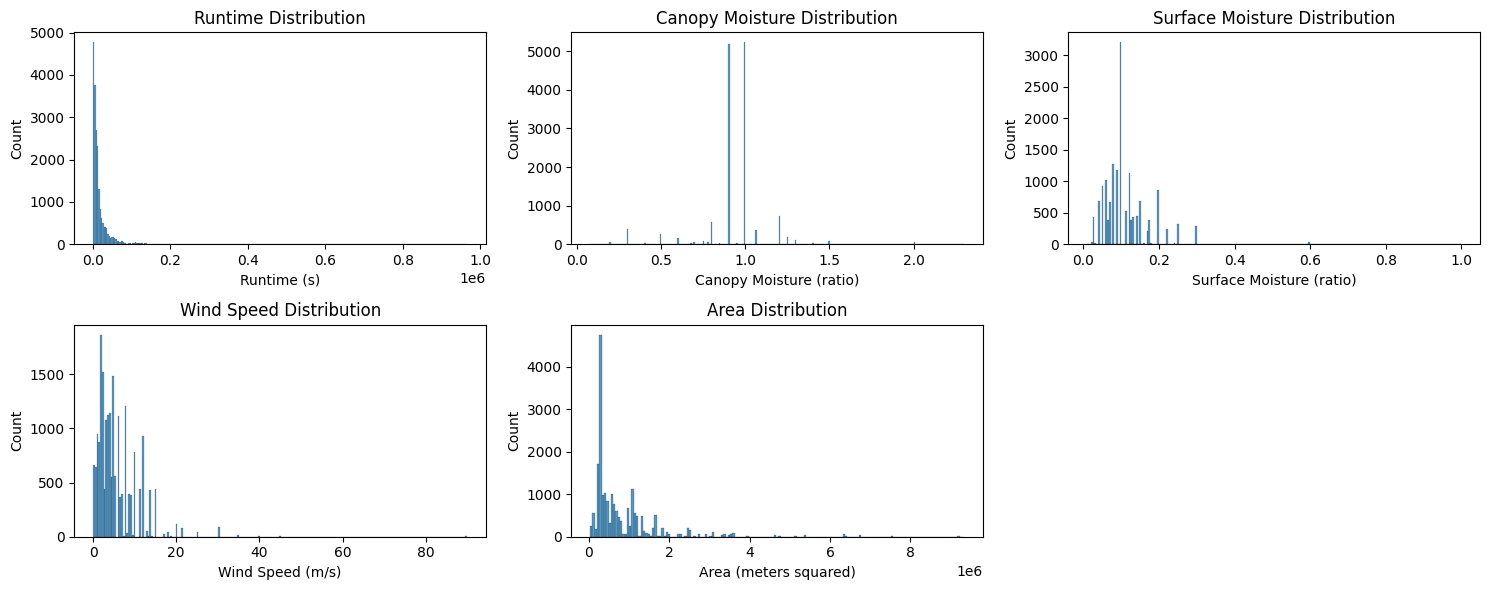

In [16]:
hist_metrics(df, app_input_cols, "runtime", "hist_inputs")

From the above plots, we can see that several predictors (wind speed, area, somewhat surface moisture) as well as the target variable (runtime) have very right-skewed distributions. Later on, depending on how the residuals behave, we may want to log transform some of these metrics. This would even out their distributions somewhat and allow for more intuitive, proportion based analysis, e.g. a 1% increase in area corresponds with an X% increase in runtime.

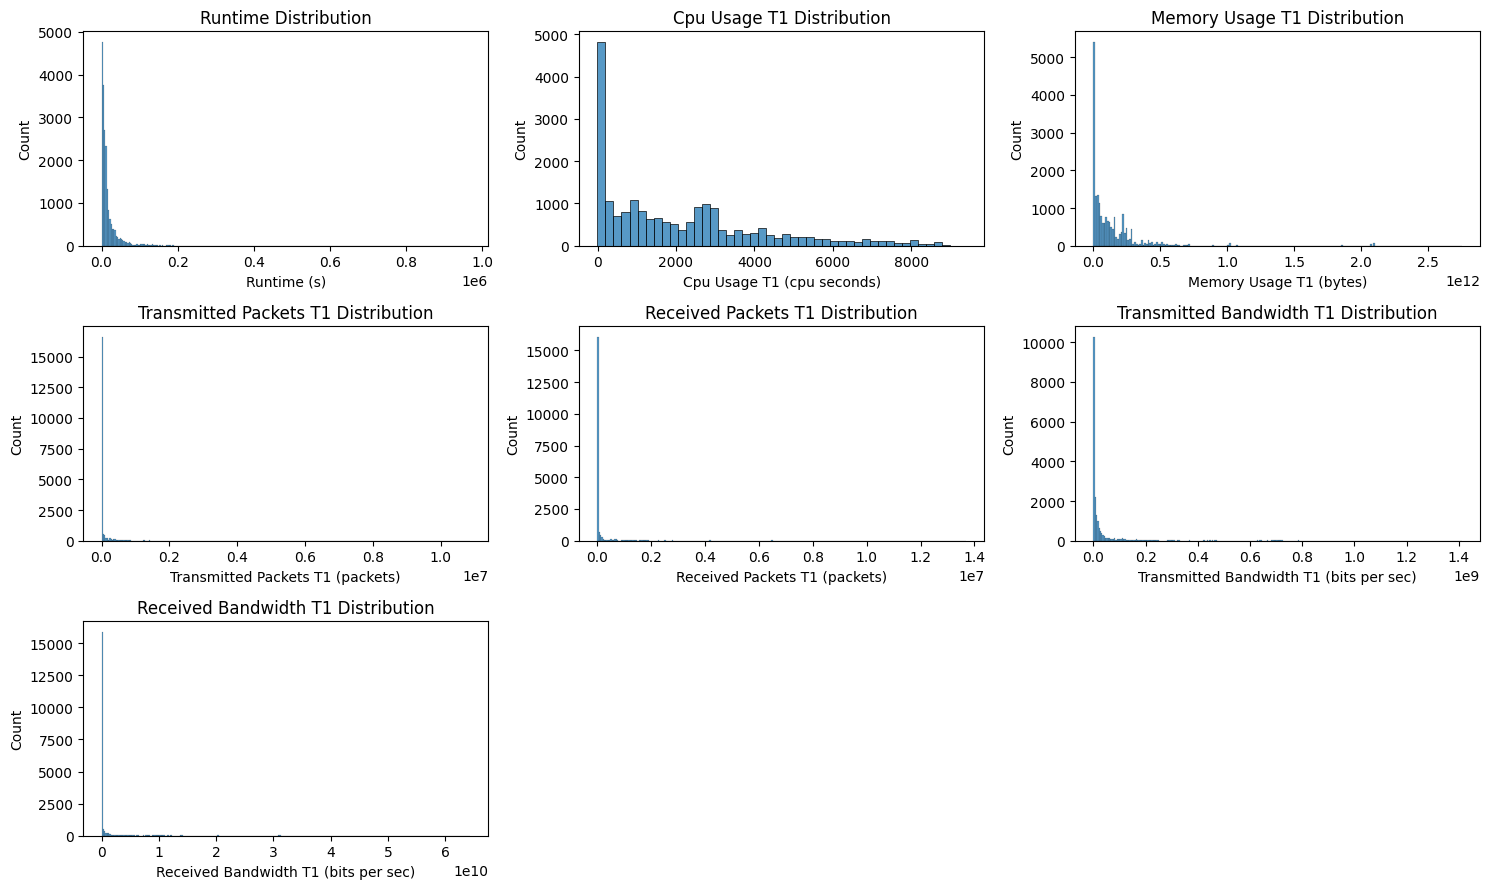

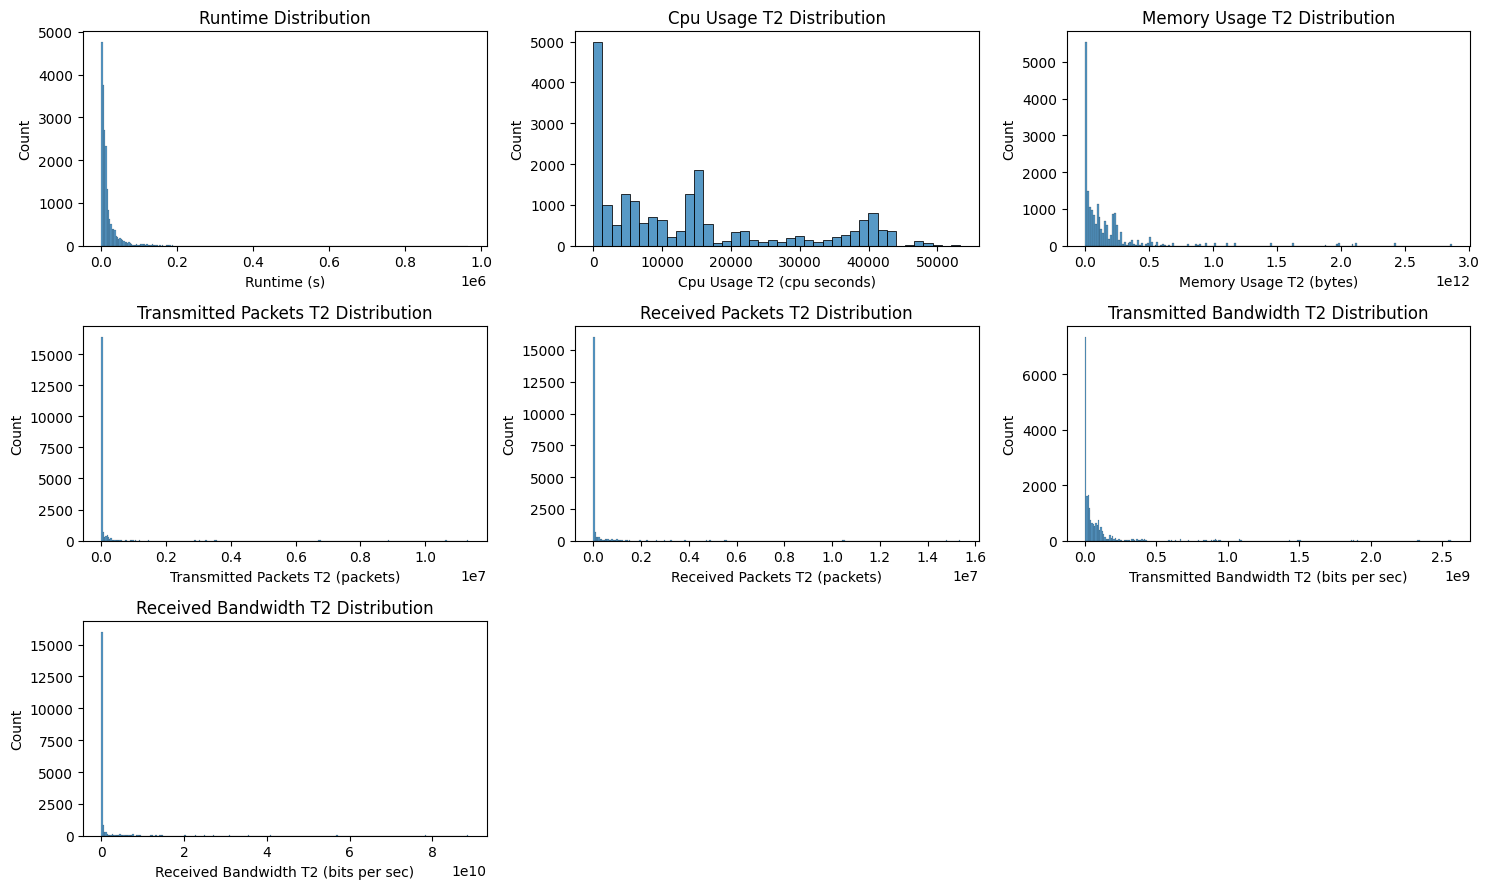

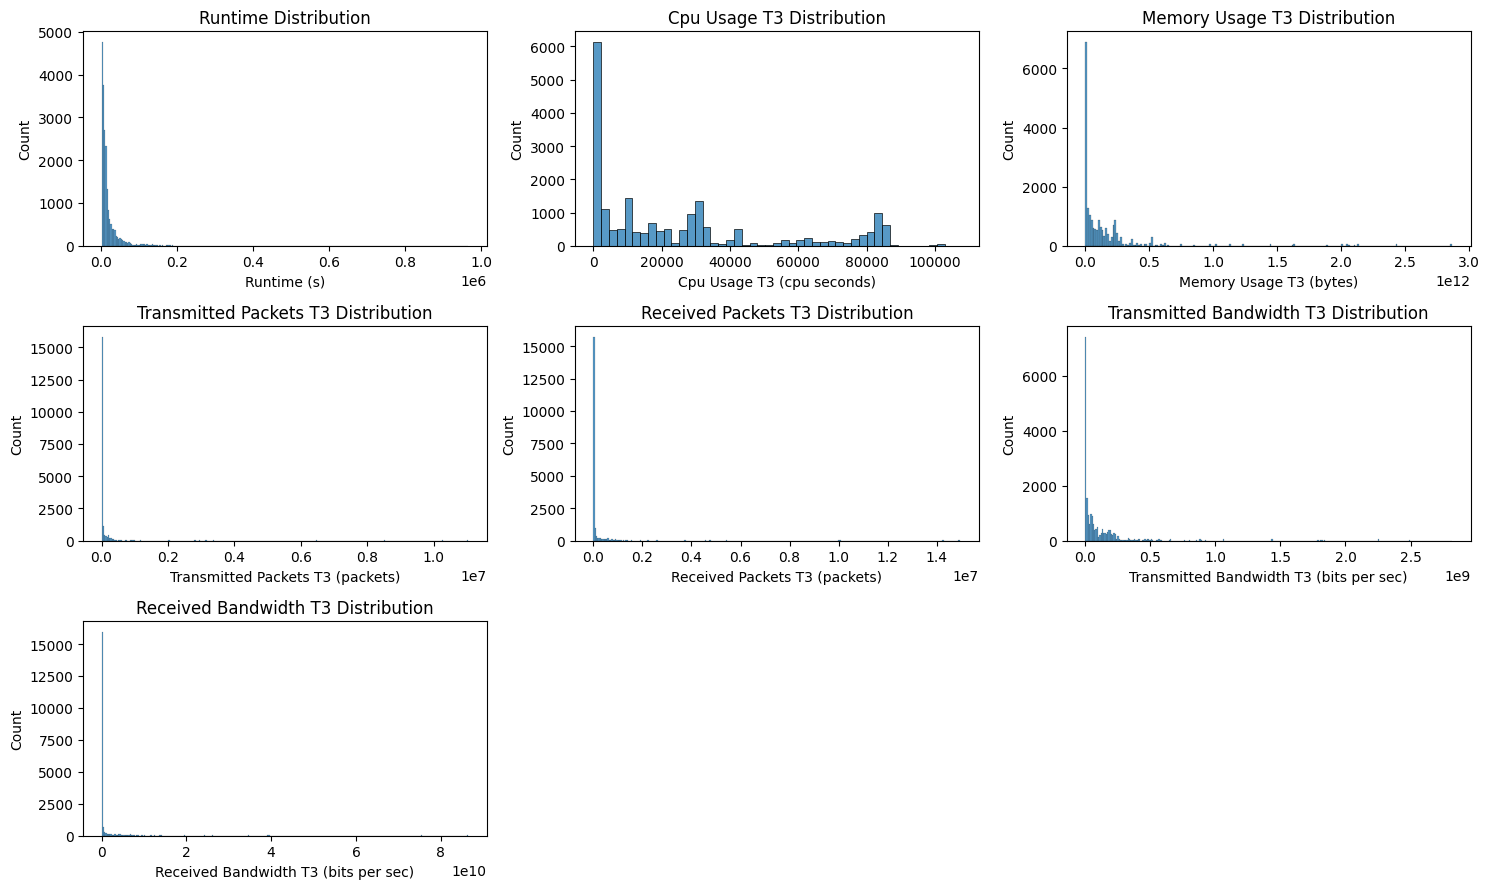

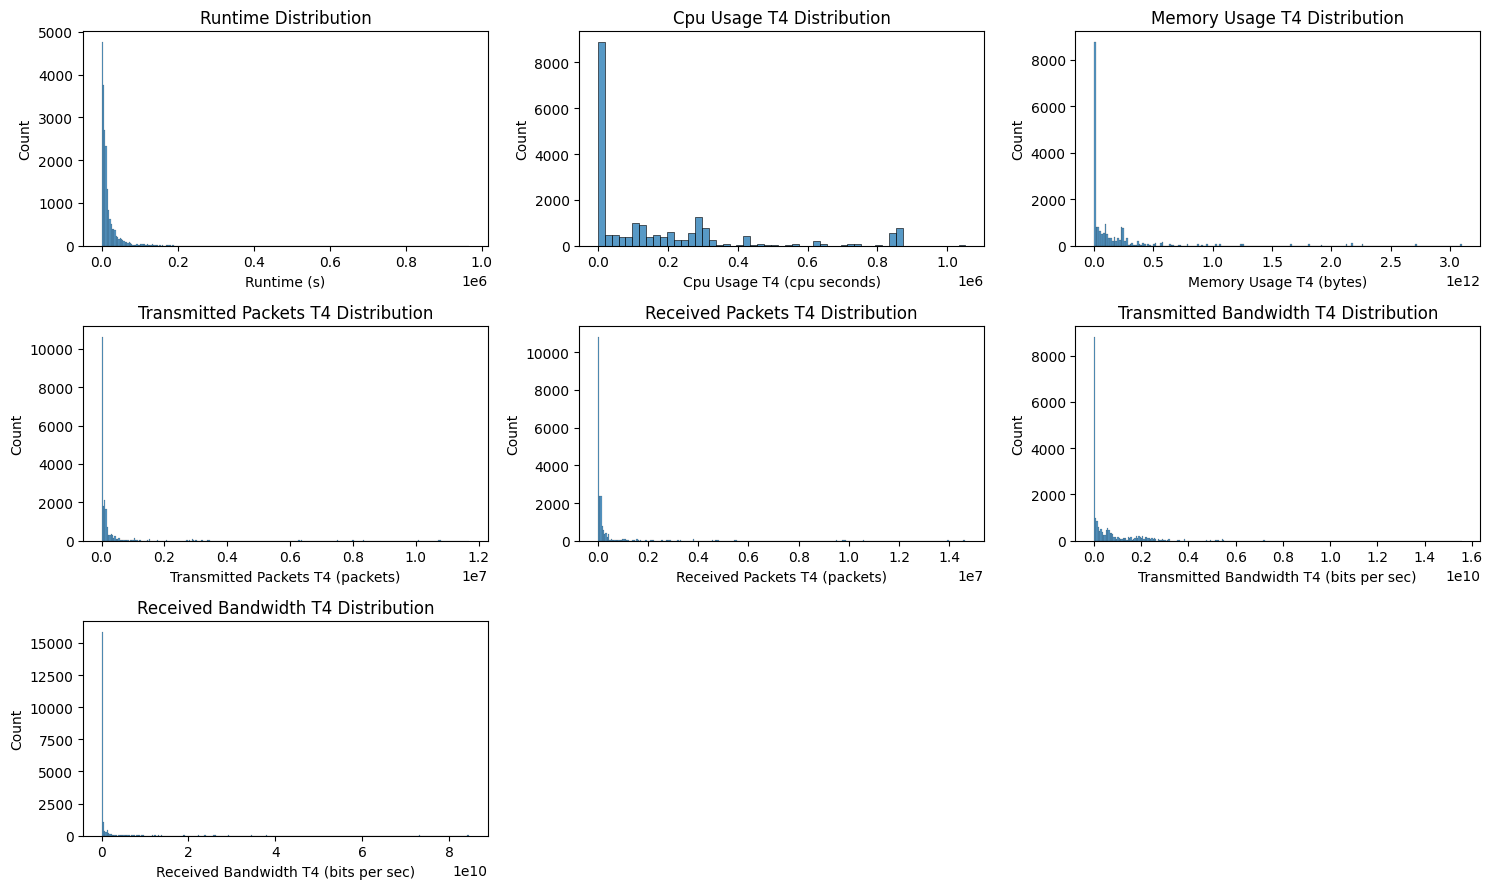

In [17]:
hist_metrics(df, t1_cols, "runtime", "hist_t1")
hist_metrics(df, t2_cols, "runtime", "hist_t2")
hist_metrics(df, t3_cols, "runtime", "hist_t3")
hist_metrics(df, t4_cols, "runtime", "hist_t4")

Most of the above plots seem to have similar distributions to runtime. This especially makes sense for cpu_usage, which is measured in cpu seconds. This will likely later be changed to cpu_usage_% (dividing by duration) to get a more usable metric. This will not be divided by cpu_request, so values like 3.00 will still be allowed, indicating 100% usage of 3 cores. This will alow for an indication that a run on 3 cores is doing more work than a run on 1 core.

For the other time specific metrics, since runtime will likely be tranformed, it is probably best to log transform these performance metrics as well. They all have quite strongly right-skewed distributions similar to an exponential pattern. This will not change their shapes to be completely uniform, but it will help even out the distribution to a certain extent.

## Scatter Plots

### Application Inputs (static)

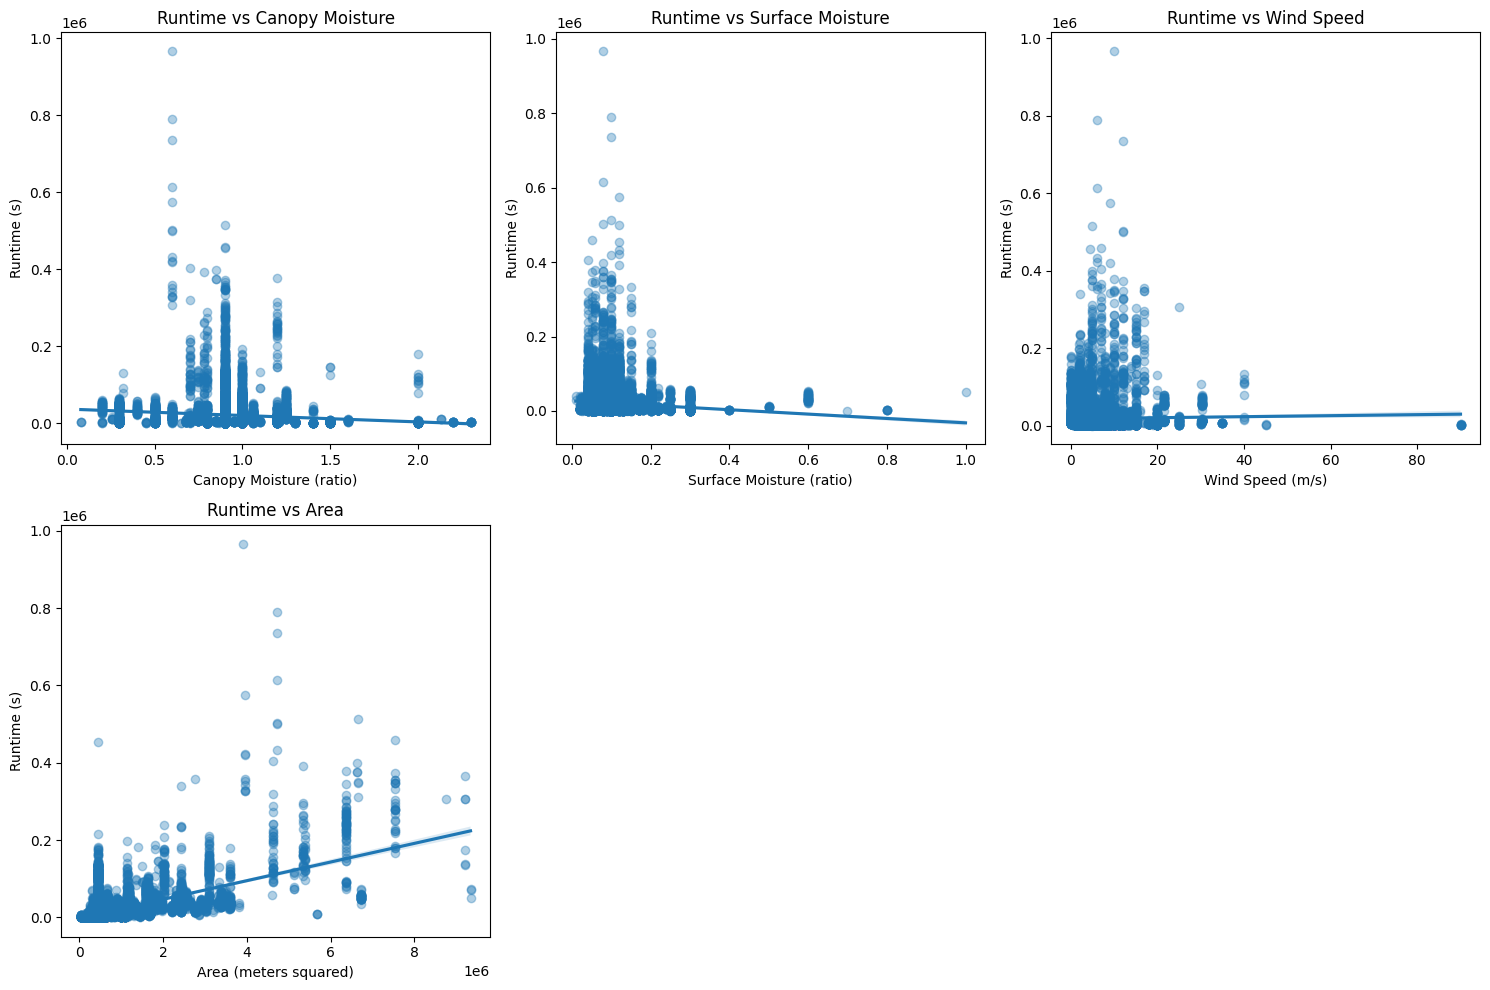

In [18]:
scatter_predictors_vs_target(df, app_input_cols, "runtime", regression_line=True, fig_title="scatter_inputs")

### Performance Metrics (Dynamic)

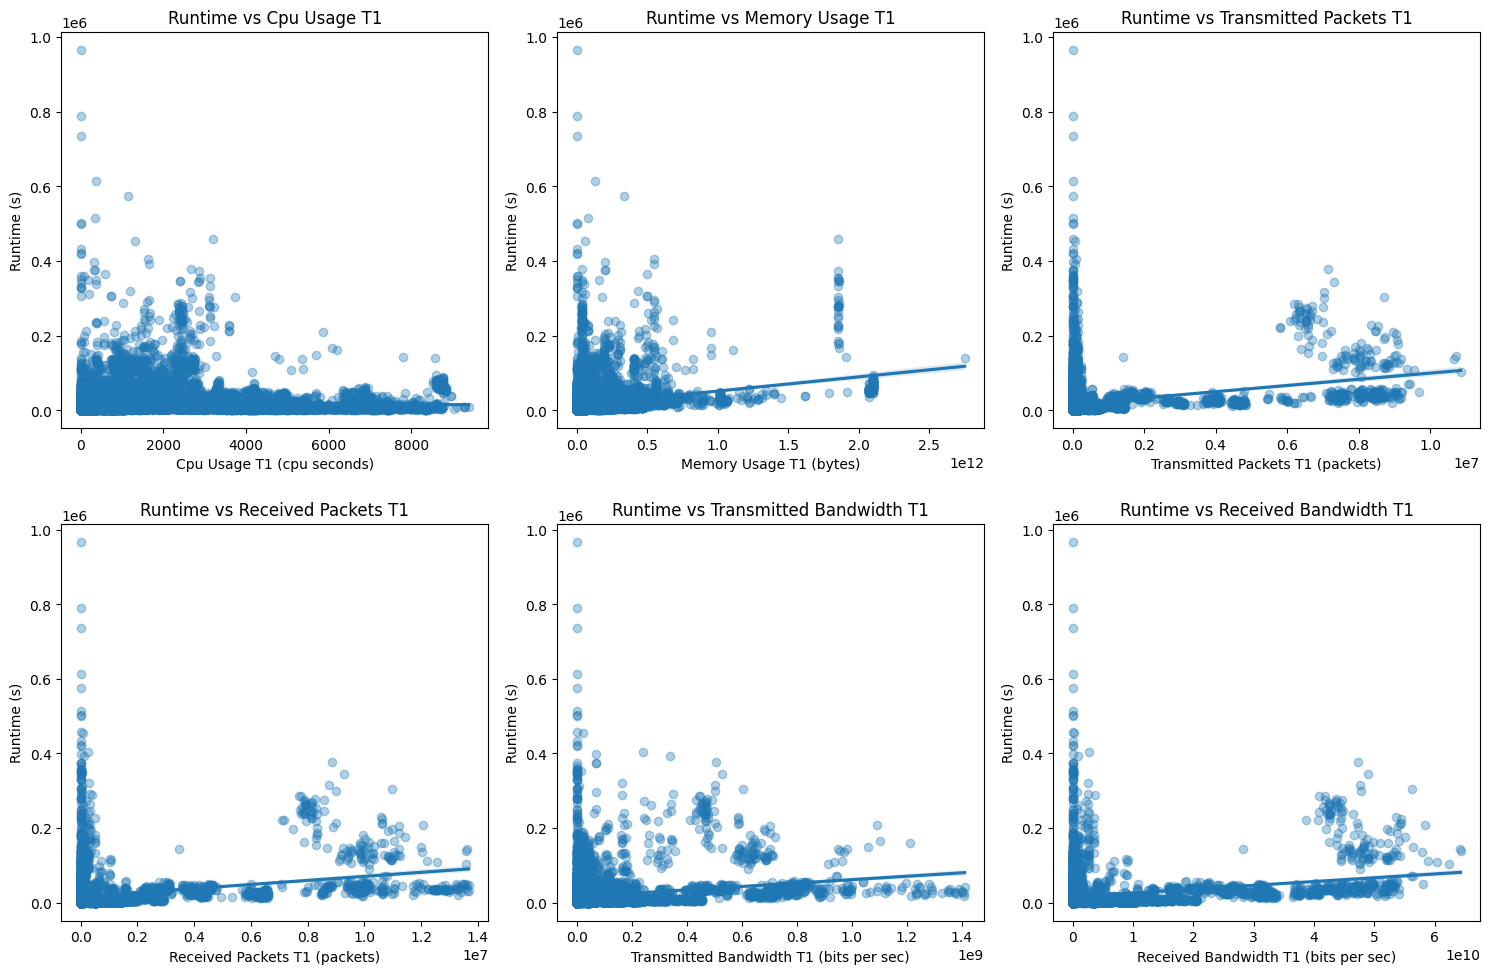

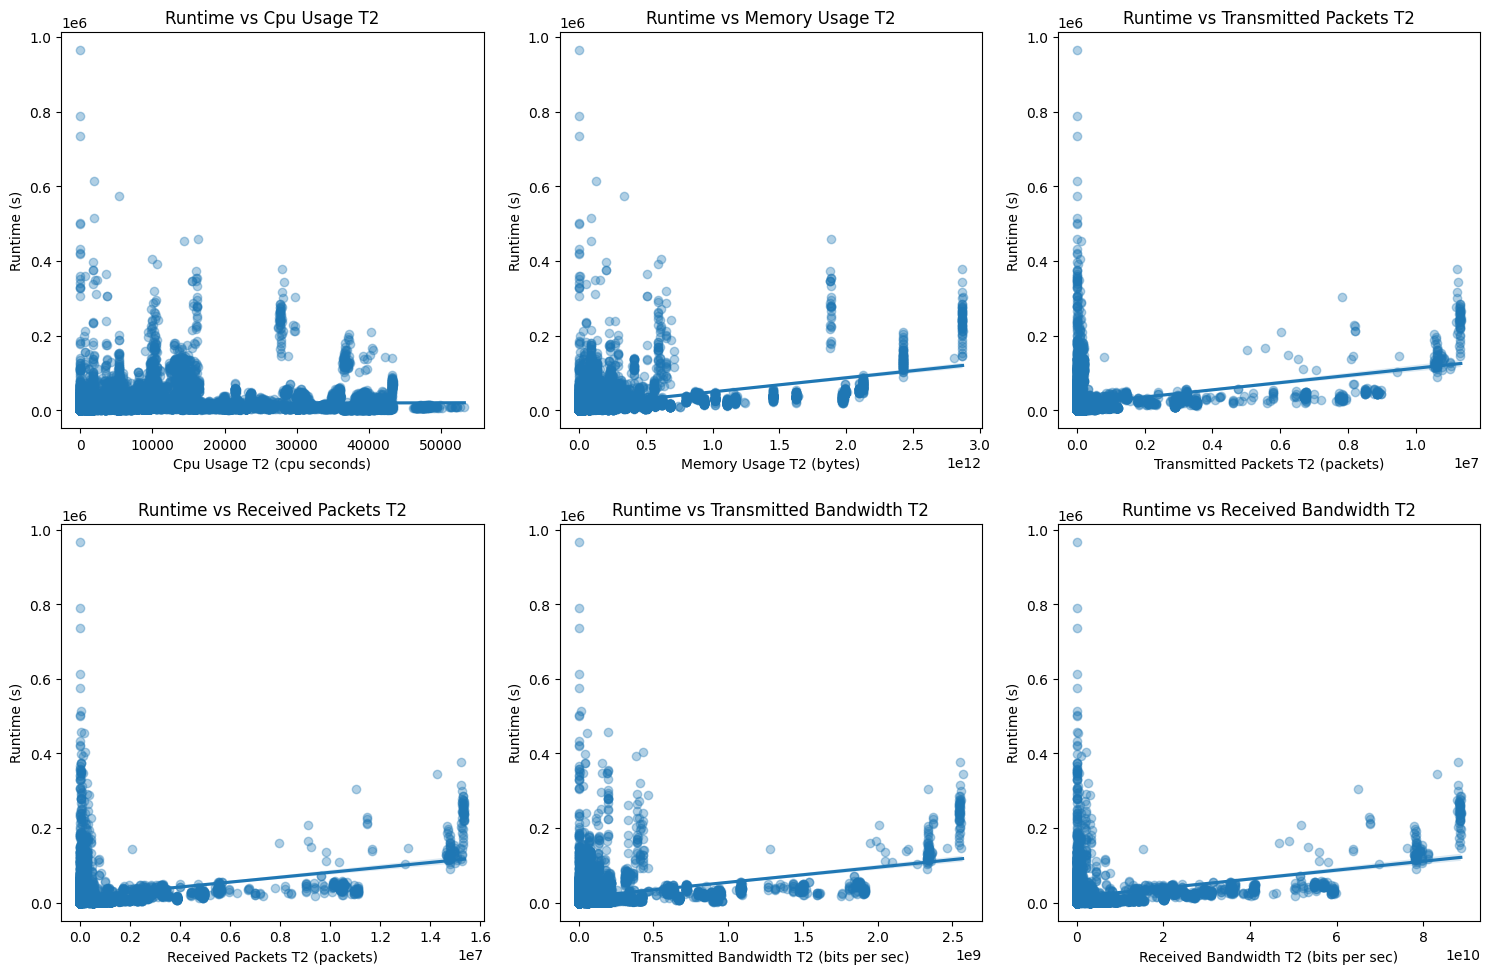

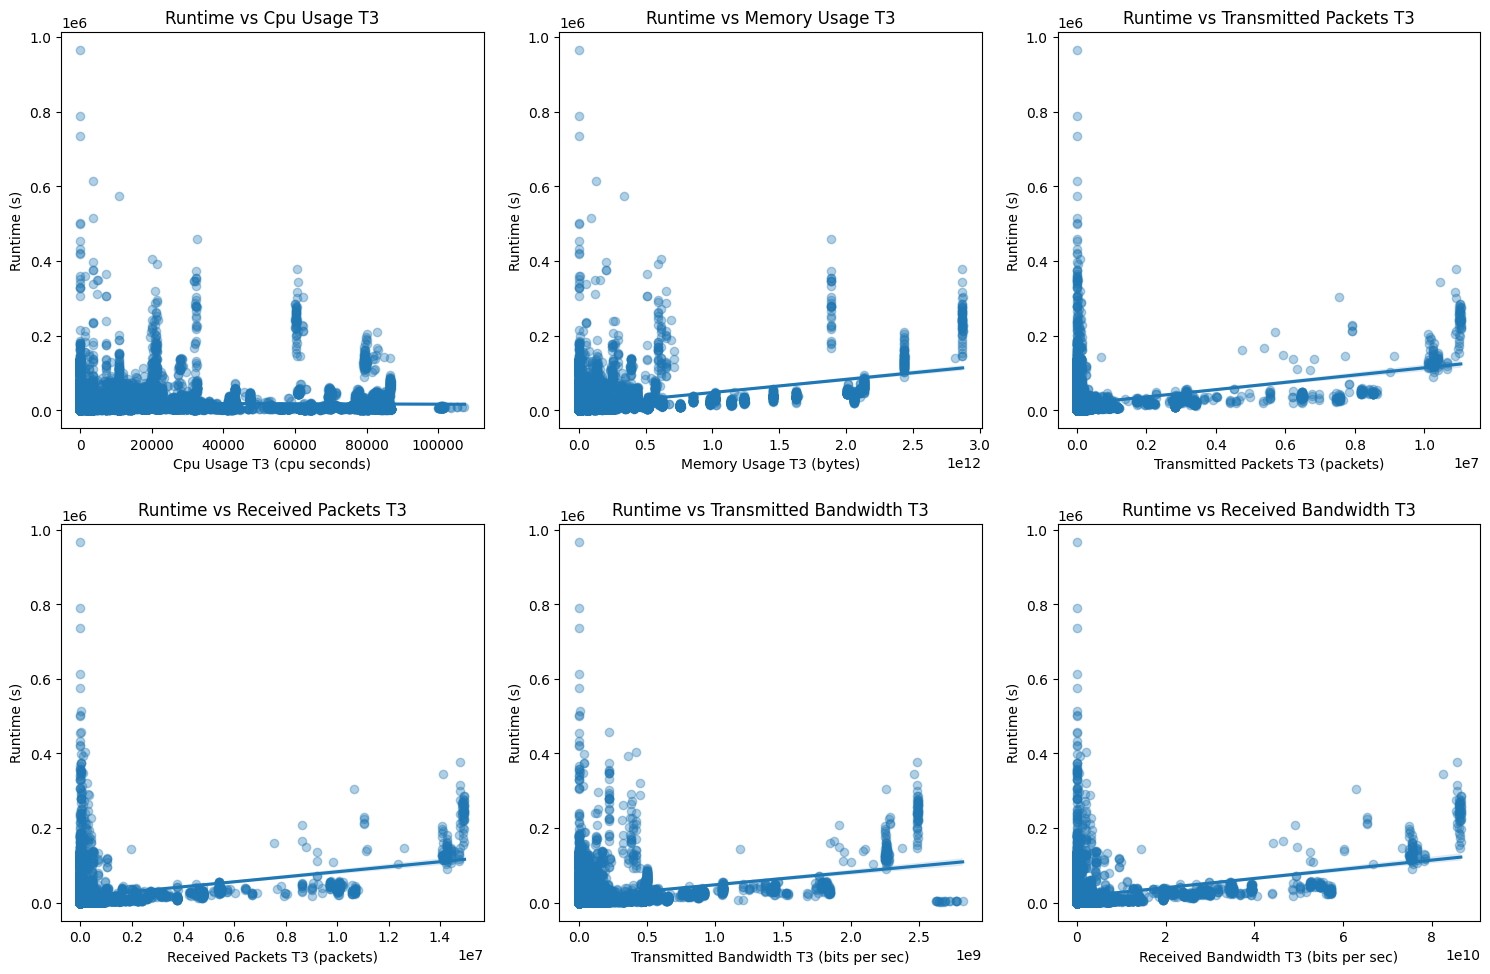

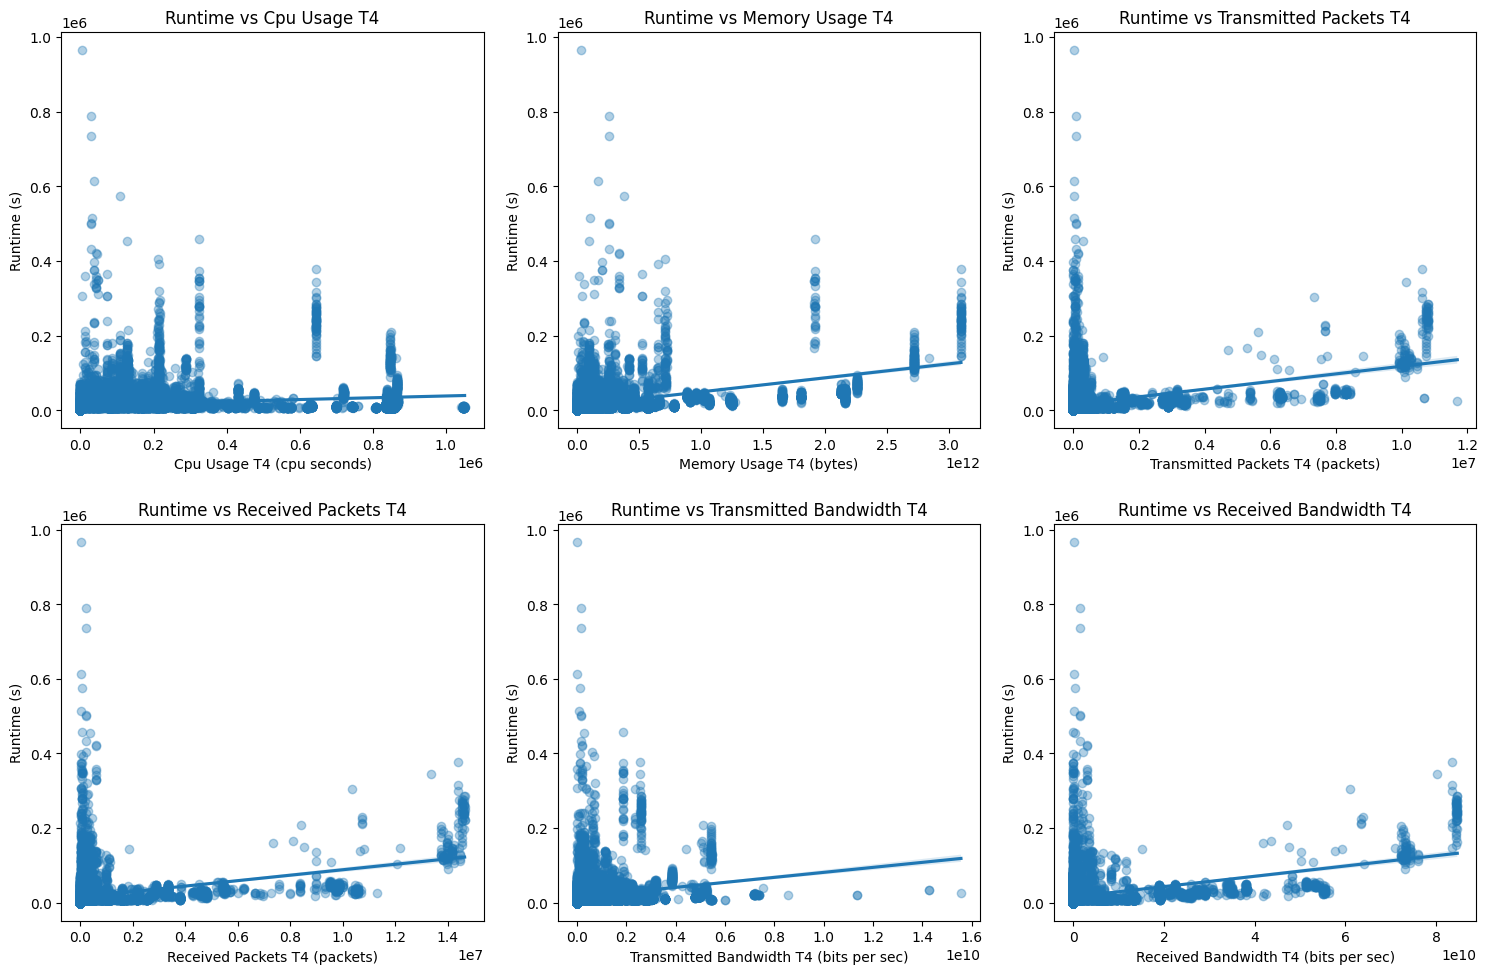

In [19]:
scatter_predictors_vs_target(df, t1_cols, "runtime", regression_line=True, fig_title="scatter_t1")
scatter_predictors_vs_target(df, t2_cols, "runtime", regression_line=True, fig_title="scatter_t2")
scatter_predictors_vs_target(df, t3_cols, "runtime", regression_line=True, fig_title="scatter_t3")
scatter_predictors_vs_target(df, t4_cols, "runtime", regression_line=True, fig_title="scatter_t4")

# Correlations

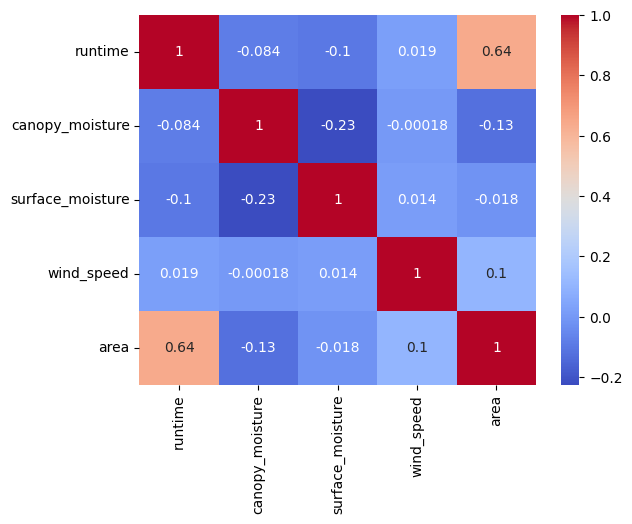

In [20]:
plot_cols = ["runtime"] + app_input_cols
sns.heatmap(df[plot_cols].corr(), annot=True, cmap='coolwarm')
save_plot("heatmap_inputs")

The above plot shows the correlation between application inputs and runtime with each other.
As we can see from the correlation heatmap, area is the most correlated static predictor with runtime. All other application inputs are not strongly correlated with runtime or each other. This means there is not much collinearity between predictors, which is ideal. However, due to the limited correlation between most predictors and the runtime, it is likely that just using these application inputs to predict runtime would not give very accurate results.

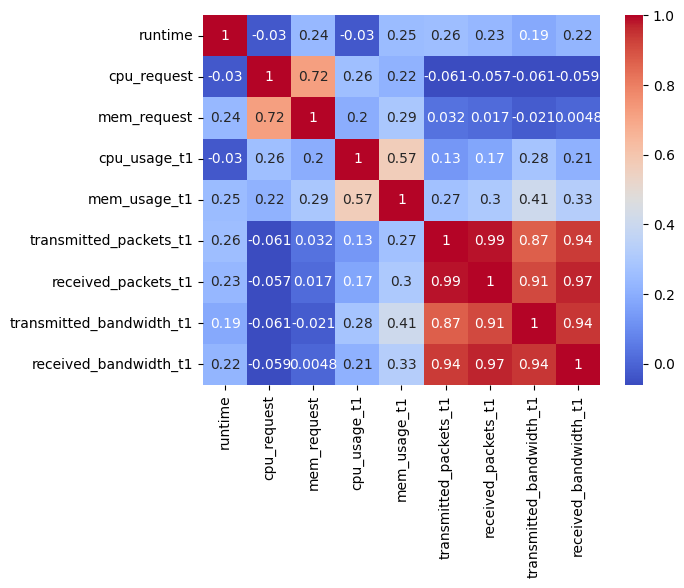

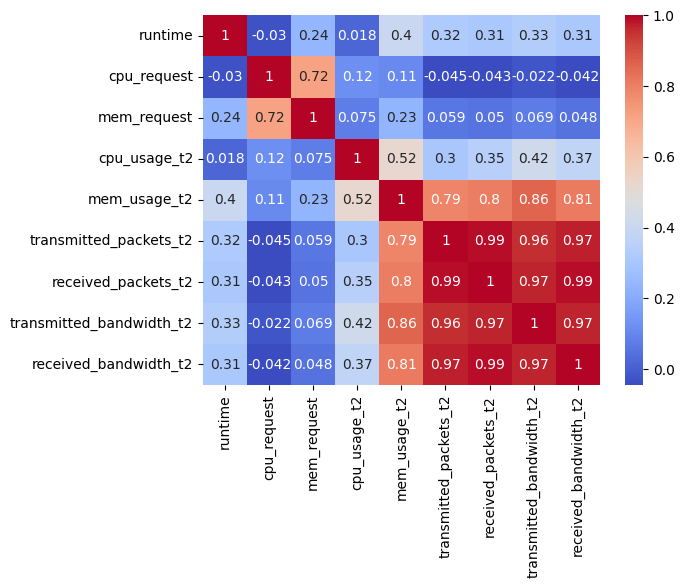

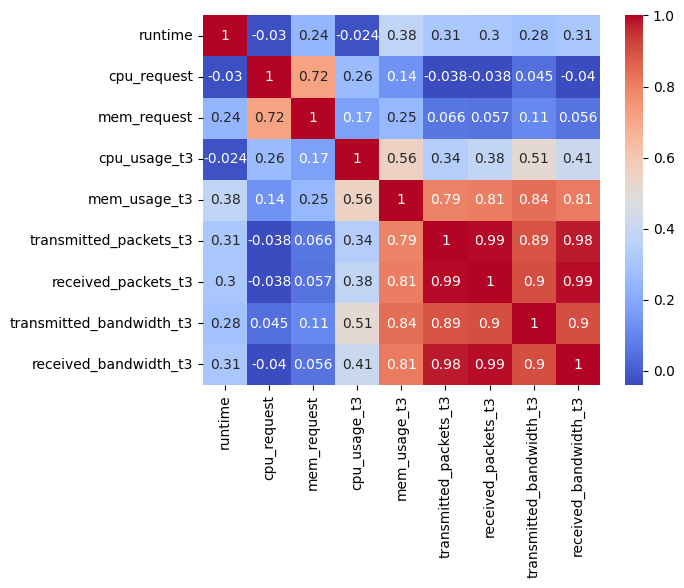

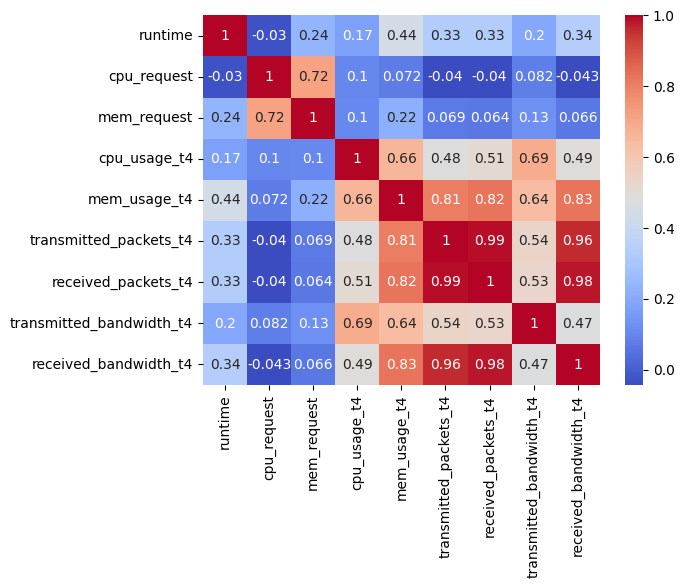

In [21]:
plot_cols_t1 = ["runtime"] + [col for col in performance_data_cols if "t1" in col or "request" in col]
plot_cols_t2 = ["runtime"] + [col for col in performance_data_cols if "t2" in col or "request" in col]
plot_cols_t3 = ["runtime"] + [col for col in performance_data_cols if "t3" in col or "request" in col]
plot_cols_t4 = ["runtime"] + [col for col in performance_data_cols if "t4" in col or "request" in col]
sns.heatmap(df[plot_cols_t1].corr(), annot=True, cmap='coolwarm')
save_plot("heatmap_t1")
plt.show()
sns.heatmap(df[plot_cols_t2].corr(), annot=True, cmap='coolwarm')
save_plot("heatmap_t2")
plt.show()
sns.heatmap(df[plot_cols_t3].corr(), annot=True, cmap='coolwarm')
save_plot("heatmap_t3")
plt.show()
sns.heatmap(df[plot_cols_t4].corr(), annot=True, cmap='coolwarm')
save_plot("heatmap_t4")
plt.show()

As we can see, there is some collinearity between some of the performance data predictors. This means it is probably best to do some feature combinations or dropping of some features. cpu_usage and mem_usage currently have relatively high correlation, but this will likely not be the case once it is transformed from cpu_usage to cpu_usage_%. As for some of the bandwidth and packets features, it is probably best to transform or drop some of these columns.

# Clustering
With PCA to create 2 dims?
 - color with runtime heatmap and texture with clusters
 - or just plot 2 graphs, one colored by runtime, one colored by clusters 